<a href="https://colab.research.google.com/github/Nahom32/Resonance-Experiments/blob/main/wheat_disease_detection/Vegetation_Prediction_CNN_and_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import torch.nn.functional as F

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
from torch.utils.data import Dataset, DataLoader
class HyperspectralDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        """
        data_dir: folder containing .npz files, one per class (e.g., leaf_rust.npz)
        Each .npz contains 'data' array of shape (n_samples, H, W, C)
        """
        self.samples = []
        self.labels = []
        self.transform = transform

        class_names = [f.split('.')[0] for f in os.listdir(data_dir) if f.endswith('.npz')]
        label_encoder = LabelEncoder()
        label_encoder.fit(class_names)

        for class_name in class_names:
            path = os.path.join(data_dir, f"{class_name}.npz")
            data = np.load(path)['data']   # (n, H, W, C)
            label = label_encoder.transform([class_name])[0]
            for i in range(data.shape[0]):
                self.samples.append(data[i])
                self.labels.append(label)

        self.samples = np.array(self.samples, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.samples[idx]          # (H, W, C)
        y = self.labels[idx]
        # Add time dimension (T=1)
        x = np.expand_dims(x, axis=0)  # (1, H, W, C)
        # Compute dummy vegetation indices (replace with your actual computation)
        # Here we generate K=5 random indices per time step as placeholder
        K = 5
        vi = np.random.randn(1, K).astype(np.float32)  # (T=1, K)
        if self.transform:
            x = self.transform(x)
        return torch.from_numpy(x), torch.from_numpy(vi), torch.tensor(y)

In [4]:
class HyperspectralTimeSeriesModel(nn.Module):
    """
    Hybrid model for hyperspectral time series classification.

    Args:
        input_shape: (T, H, W, B) – time steps, height, width, spectral bands
        n_vegetation_indices: K – number of vegetation indices per time step
        patch_size: P – size of non-overlapping patches (P x P)
        n_classes: number of disease classes
        lstm_hidden: hidden size for LSTM (default 128)
        mlp_hidden: hidden size for MLP in vegetation branch (default 128)
        dropout_rate: dropout probability for Monte Carlo (default 0.3)
    """
    def __init__(self, input_shape, n_vegetation_indices, patch_size,
                 n_classes, lstm_hidden=128, mlp_hidden=128, dropout_rate=0.3):
        super().__init__()
        T, H, W, B = input_shape
        self.patch_size = patch_size
        self.dropout_rate = dropout_rate

        # ---- Spatial-temporal branch (left) ----
        # Compute number of patches
        self.n_patches_h = H // patch_size
        self.n_patches_w = W // patch_size
        self.n_patches = self.n_patches_h * self.n_patches_w
        # After mean pooling per patch, we have shape (T, n_patches, B)

        # Small CNN: 2 conv layers + Global Average Pooling
        # Input channels = B, output channels = 128 (as per diagram s_t in R^128)
        self.conv1 = nn.Conv2d(B, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.gap = nn.AdaptiveAvgPool2d(1)   # output (T, 64, 1, 1) -> squeeze
        # Final projection to 128
        self.fc_s = nn.Linear(64, 128)

        # Combined CNN module for the spatial-temporal branch
        self.cnn = nn.Sequential(
            self.conv1,
            nn.ReLU(),
            self.conv2,
            nn.ReLU(),
            self.gap,
            nn.Flatten(),
            self.fc_s
        )

        # LSTM over time steps
        self.lstm = nn.LSTM(input_size=128, hidden_size=lstm_hidden,
                            num_layers=1, batch_first=True)
        self.fc_e = nn.Linear(lstm_hidden, 128)   # map to 128 for fusion

        # ---- Vegetation indices branch (right) ----
        # 1D CNN over time: input (T, K) -> (T, filters)
        # Using 3 layers with 32, 64, 128 filters
        self.conv1d_1 = nn.Conv1d(in_channels=n_vegetation_indices, out_channels=32,
                                  kernel_size=3, padding=1)
        self.conv1d_2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.conv1d_3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)

        # MLP: 128 -> 64 -> 128 (as per diagram)
        self.mlp = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 128)
        )

        # Attention over time (producing context vector u of size 128)
        self.attention = nn.Sequential(
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        # ---- Gated fusion ----
        # g = sigmoid(W_g [e; u])   ;   h = g * e + (1-g) * u
        self.fusion_gate = nn.Linear(256, 128)  # maps concatenated [e, u] to gate vector
        self.fc_out = nn.Linear(128, n_classes)

        # Dropout for Monte Carlo
        self.dropout = nn.Dropout(dropout_rate)

    def extract_patches_and_pool(self, x):
        """
        Input:
            x: (T, H, W, B) or (batch, T, H, W, B)
        Returns:
            patches: (T, n_patches, B) or (batch, T, n_patches, B)
        """
        # Check dimensions
        if x.dim() == 5:
            # Batched input
            batch_size, T, H, W, B = x.shape
            P = self.patch_size
            n_h = H // P
            n_w = W // P
            # Reshape to (batch * T, H, W, B) for efficient unfolding
            x_flat = x.view(batch_size * T, H, W, B)
            # Permute to (batch * T, B, H, W) for CNN input if needed later
            x_flat = x_flat.permute(0, 3, 1, 2) # (batch*T, B, H, W)
            # Unfold patches - will get (batch*T, B, n_h, n_w, P, P)
            patches_flat = x_flat.unfold(2, P, P).unfold(3, P, P)
            patches_flat = patches_flat.mean(dim=(-1, -2)) # (batch*T, B, n_h, n_w)
            patches_flat = patches_flat.permute(0, 2, 3, 1) # (batch*T, n_h, n_w, B)
            patches_flat = patches_flat.contiguous().view(batch_size * T, n_h * n_w, B)
            # Reshape back to (batch, T, n_patches, B)
            patches = patches_flat.view(batch_size, T, n_h * n_w, B)
            return patches
        else:
            # Single sample (T, H, W, B)
            T, H, W, B = x.shape
            P = self.patch_size
            n_h = H // P
            n_w = W // P
            x = x.permute(0, 3, 1, 2) # (T, B, H, W)
            patches = x.unfold(2, P, P).unfold(3, P, P) # (T, B, n_h, n_w, P, P)
            patches = patches.mean(dim=(-1, -2)) # (T, B, n_h, n_w)
            patches = patches.permute(0, 2, 3, 1) # (T, n_h, n_w, B)
            patches = patches.contiguous().view(T, n_h * n_w, B) # (T, n_patches, B)
            return patches

    def spatial_temporal_branch(self, x):
        """
        x: (batch, T, H, W, B)
        Returns: (batch, 128) temporal embedding 'e'
        """
        batch_size, T, H, W, B = x.shape

        # Patch extraction & mean pooling
        patches = self.extract_patches_and_pool(x)  # (batch, T, n_patches, B)
        n_patches = patches.shape[2]

        # Reshape to (batch * T, B, n_patches, 1) for CNN input
        # Assuming each 'patch' of B bands is fed through the CNN, treating n_patches as a spatial dimension, but the CNN expects H, W
        # Let's clarify the CNN input: the diagram shows s_t in R^128 from a small CNN, which implies per time step.
        # The patches are (batch, T, n_patches, B). If the small CNN processes each (n_patches, B) set for a given time step,
        # then we need to reshape. Let's assume the CNN works on (batch_dim, B, H_eff, W_eff)
        # A common way is to average over patches first if the CNN is applied per (H,W) slice, not per patch itself.
        # Re-interpreting the diagram for 'small CNN'
        # The diagram has s_t for each time step. The small CNN takes the (H,W,B) image of a timestep.
        # This means the CNN should operate on (batch*T, B, H, W).
        # Given `input_shape=(T, H, W, B)`, the input `x` to `forward` is `(batch, T, H, W, B)`.
        # We need to process each (H,W,B) image from each time step `T` for each sample in `batch`.

        # Reshape x to (batch * T, H, W, B) and permute to (batch * T, B, H, W) for CNN
        cnn_input = x.view(batch_size * T, H, W, B).permute(0, 3, 1, 2) # (batch*T, B, H, W)

        # Apply CNN
        cnn_output = self.cnn(cnn_input) # (batch*T, 128) as self.fc_s output

        # Reshape back to (batch, T, 128) for LSTM
        s_t = cnn_output.view(batch_size, T, 128)

        # Apply dropout
        s_t = self.dropout(s_t)

        # Temporal LSTM
        lstm_out, (h_n, c_n) = self.lstm(s_t)  # lstm_out: (batch, T, lstm_hidden)

        # Take the hidden state of the last time step
        # h_n shape: (num_layers, batch, hidden_size). Since num_layers=1, it's (1, batch, hidden_size)
        e = self.fc_e(h_n.squeeze(0)) # (batch, 128)

        return e

    def vegetation_branch(self, vi):
        """
        vi: (batch, T, K) – vegetation indices over time
        Returns: (batch, 128) context vector 'u' after attention
        """
        batch_size, T, K = vi.shape

        # 1D CNN expects (batch, channels, sequence)
        vi_input = vi.permute(0, 2, 1)  # (batch, K, T)

        out = F.relu(self.conv1d_1(vi_input))
        out = F.relu(self.conv1d_2(out))
        out = F.relu(self.conv1d_3(out))
        out = out.permute(0, 2, 1)  # (batch, T, 128)

        # Apply dropout
        out = self.dropout(out)

        # MLP
        out = self.mlp(out)  # (batch, T, 128)

        # Attention over time
        attn_weights = self.attention(out)  # (batch, T, 1)
        attn_weights = F.softmax(attn_weights, dim=1)

        # Weighted sum
        u = (out * attn_weights).sum(dim=1)  # (batch, 128)

        return u

    def forward(self, x, vi, mc_dropout=False):
        # x: (batch, T, H, W, B)
        # vi: (batch, T, K)

        if mc_dropout:
            self.train() # Enable dropout for MC dropout
        else:
            self.eval() # Disable dropout for inference unless MC dropout is active

        # Spatial-temporal branch
        e = self.spatial_temporal_branch(x)   # (batch, 128)

        # Vegetation indices branch
        u = self.vegetation_branch(vi)        # (batch, 128)

        # Gated fusion
        # Concatenate e and u
        combined = torch.cat((e, u), dim=1) # (batch, 256)

        # Compute gate vector g
        g = torch.sigmoid(self.fusion_gate(combined)) # (batch, 128)

        # Compute fused representation h
        h = g * e + (1 - g) * u # (batch, 128)

        # Final classifier
        logits = self.fc_out(h) # (batch, n_classes)

        return logits

    def predict_with_uncertainty(self, x, vi, n_passes=30):
        """
        Monte Carlo dropout for uncertainty estimation.
        Returns: mean_probs, variance (or entropy)
        """
        self.train() # Ensure dropout is active for MC dropout
        logits_list = []
        for _ in range(n_passes):
            logits = self.forward(x, vi, mc_dropout=True)
            logits_list.append(logits.unsqueeze(0))

        logits = torch.cat(logits_list, dim=0)  # (n_passes, batch, n_classes)
        probs = F.softmax(logits, dim=-1)

        mean_probs = probs.mean(dim=0) # (batch, n_classes)
        variance = probs.var(dim=0)    # (batch, n_classes)

        # Calculate entropy for each sample in the batch
        # Add a small epsilon to prevent log(0) issues
        entropy = - (mean_probs * torch.log(mean_probs + 1e-8)).sum(dim=-1)

        return mean_probs, variance, entropy

In [5]:
torch.backends.cudnn.enabled = False
def train_model(model, train_loader, test_loader, epochs, lr=1e-3, device='cuda'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for x, vi, y in train_loader:
            x, vi, y = x.to(device), vi.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x, vi)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        epoch_train_loss = running_loss / total
        epoch_train_acc = 100 * correct / total
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # Testing
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for x, vi, y in test_loader:
                x, vi, y = x.to(device), vi.to(device), y.to(device)
                outputs = model(x, vi)
                loss = criterion(outputs, y)
                running_loss += loss.item() * x.size(0)
                _, predicted = torch.max(outputs, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        epoch_test_loss = running_loss / total
        epoch_test_acc = 100 * correct / total
        test_losses.append(epoch_test_loss)
        test_accs.append(epoch_test_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2f}% | Test Loss: {epoch_test_loss:.4f} Acc: {epoch_test_acc:.2f}%")

    # Plotting
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
    plt.plot(range(1, epochs+1), test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curves')

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), train_accs, label='Train Accuracy')
    plt.plot(range(1, epochs+1), test_accs, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.title('Accuracy Curves')
    plt.tight_layout()
    plt.show()

    return model, train_losses, test_losses, train_accs, test_accs

Found 7 classes, 1010 samples
Using device: cuda
Epoch 1/30 | Train Loss: 1.5941 Acc: 32.30% | Test Loss: 1.1966 Acc: 49.01%
Epoch 2/30 | Train Loss: 1.0213 Acc: 50.50% | Test Loss: 0.9008 Acc: 50.50%
Epoch 3/30 | Train Loss: 0.8110 Acc: 58.29% | Test Loss: 0.6202 Acc: 66.34%
Epoch 4/30 | Train Loss: 0.6802 Acc: 69.68% | Test Loss: 0.5460 Acc: 76.73%
Epoch 5/30 | Train Loss: 0.5058 Acc: 77.48% | Test Loss: 0.3272 Acc: 87.13%
Epoch 6/30 | Train Loss: 0.3670 Acc: 84.65% | Test Loss: 0.2438 Acc: 92.08%
Epoch 7/30 | Train Loss: 0.2933 Acc: 89.11% | Test Loss: 0.1932 Acc: 90.59%
Epoch 8/30 | Train Loss: 0.3112 Acc: 87.75% | Test Loss: 0.3584 Acc: 85.15%
Epoch 9/30 | Train Loss: 0.2526 Acc: 89.98% | Test Loss: 0.1722 Acc: 92.57%
Epoch 10/30 | Train Loss: 0.1476 Acc: 93.56% | Test Loss: 0.1035 Acc: 95.05%
Epoch 11/30 | Train Loss: 0.1913 Acc: 93.56% | Test Loss: 0.0407 Acc: 100.00%
Epoch 12/30 | Train Loss: 0.1273 Acc: 95.92% | Test Loss: 0.0523 Acc: 98.51%
Epoch 13/30 | Train Loss: 0.0910 Ac

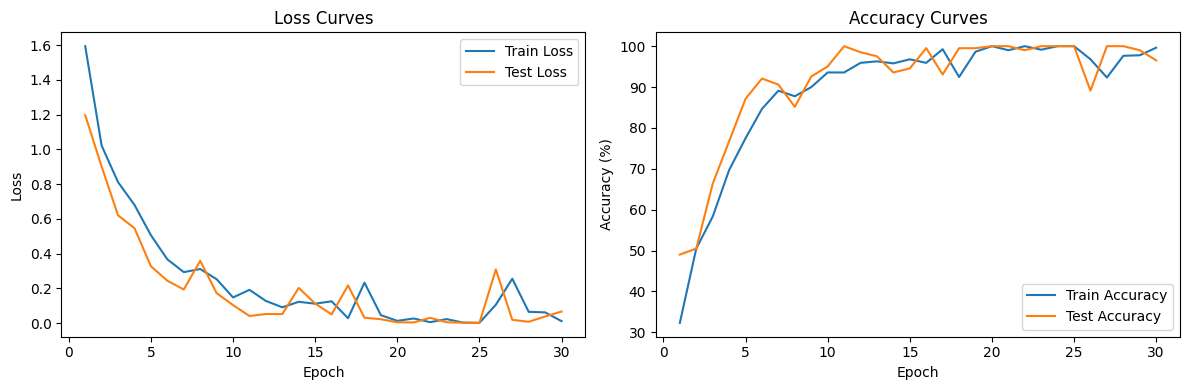

In [6]:
if __name__ == "__main__":

    DATA_DIR = "/content/drive/MyDrive/wheat_reduced"


    H, W = 128, 128
    C = 10
    T = 1
    K = 5
    PATCH_SIZE = 8
    N_CLASSES = None

    # Create dataset and split
    full_dataset = HyperspectralDataset(DATA_DIR)
    N_CLASSES = len(np.unique(full_dataset.labels))
    print(f"Found {N_CLASSES} classes, {len(full_dataset)} samples")

    train_size = int(0.8 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

    # Model
    input_shape = (T, H, W, C)
    model = HyperspectralTimeSeriesModel(
        input_shape=input_shape,
        n_vegetation_indices=K,
        patch_size=PATCH_SIZE,
        n_classes=N_CLASSES,
        lstm_hidden=128,
        mlp_hidden=128,
        dropout_rate=0.4
    )

    # Train
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model, _, _, _, _ = train_model(model, train_loader, test_loader, epochs=30, lr=1e-3, device=device)